# Notebook to investigate House Prices Tutorial Competition

In this notebook, I look into the tutorial competition for predicting house prices

## Code from Kaggle

The cell below was automatically generated when I created a new notebook. Let's ignore it for now

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
input_dir = '../input/'  # Use './' for submission
for dirname, _, filenames in os.walk(input_dir):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a
# version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

../input/house-prices-advanced-regression-techniques/test.csv
../input/house-prices-advanced-regression-techniques/data_description.txt
../input/house-prices-advanced-regression-techniques/train.csv
../input/house-prices-advanced-regression-techniques/sample_submission.csv


## Exploratory Data Analysis (EPA)

Let's dedicate some time to understand the data first.

### Getting features

We will get the features from the `data_description.txt` file first, as they will help us distinguish between continuous and categorical features, as well as help read in the data.

In [2]:
with open(input_dir + 'house-prices-advanced-regression-techniques/data_description.txt', 'r') as data_description_file:
    raw_desc_lines = data_description_file.readlines()  # Read all lines
    data_description_file.close()

print(f'Read in {len(raw_desc_lines)} lines')

Read in 523 lines


Let's clean up the lines a bit to remove all blank lines.

In [3]:
dense_desc_lines = [line for line in raw_desc_lines if len(line.strip('\n \t')) != 0]
print(f'Obtained {len(dense_desc_lines)} information-rich lines.')

Obtained 399 information-rich lines.


The categorical features will have the categories specified in the subsequent lines, while the continuous features occuply only one line. 

In [4]:
# Prepare a dictionary to store the features we find
features_info = {'continuous': [],
                 'categorical': {}}

# Let's go through the lines and add them to the features
line_number = 0

# Auxiliary variable to tell us if we are reading a category from a feature
reading_category = False
last_cat_feature = None

while line_number < len(dense_desc_lines):
    # Get the content
    line_content = dense_desc_lines[line_number]

    # If we are not currently reading a feature
    if (line_content.lstrip(' ') == line_content):
        feat_name = line_content.split(':')[0]
        # Check if the next line starts with a space
        next_line_number = line_number + 1
        if next_line_number == len(dense_desc_lines):  # reached EOF in a continous feature
            features_info['continuous'].append(feat_name)
            break
        next_line = dense_desc_lines[next_line_number]
        # If the next line starts with a space, we have a category
        if next_line[0] == ' ':
            last_cat_feature = feat_name
            features_info['categorical'][last_cat_feature] = {}
            reading_category = True
        # Otherwise, it's a continuous feature
        else:
            features_info['continuous'].append(feat_name)
            reading_category = False

    # If we are reading a category, let's make sure we process it correctly
    else:
        cat = line_content.split('\t')[0].strip(' ')
        cat_desc = line_content.split('\t')[1].strip(' \n')
        features_info['categorical'][last_cat_feature][cat] = cat_desc

    # Go to next line
    line_number += 1

In [5]:
print(f"Found {len(features_info['continuous'])} continous features")
print(f"Found {len(features_info['categorical'])} categorical features")

Found 33 continous features
Found 46 categorical features


Ok, so we retrieved the features correctly, as there are 79 of them (the original table had 81 columns, including `'Id'` and the target variable)

I happen to know there is a small issue in the continuous features: the `'Bedroom'` and `'Kitchen'` are called something different in the data. Let's fix that by hand.

In [6]:
bed_id = features_info['continuous'].index('Bedroom')
kit_id = features_info['continuous'].index('Kitchen')

features_info['continuous'][bed_id] = 'BedroomAbvGr'
features_info['continuous'][kit_id] = 'KitchenAbvGr'

Additionally, there are two features, `'OverallQual'` and `'OverallCond'` that, based on the `.txt` file, appear to be categorical, but their values are integers between 1 and 10, so we should be fine treating them as continuous. Let's also update that by hand.

In [7]:
for feat in ['OverallQual', 'OverallCond']:
    assert feat in features_info['categorical'].keys(), f'Missing {feat} from categorical features!'
    features_info['continuous'].append(feat)
    _ = features_info['categorical'].pop(feat)

### Reading in data

First, let's make sure that, for the continuous features, strings like `' '`, `'NA'`, `'N/A'`, `'NULL'`, etc. are properly interpreted as `NaN`. For the categorical features, we need to make sure those are considered separate categories.

In [8]:
na_values = dict.fromkeys(features_info['continuous'], [' ', 'NA', 'N/A', 'Null', 'NULL'])

full_training = pd.read_csv(input_dir + 'house-prices-advanced-regression-techniques/train.csv',
                            keep_default_na=False,  # Recall some of the categories are 'NA'
                            na_values=na_values,
                            )
num_entries = full_training.shape[0]

print(f'Total number of entries in traning data = {num_entries}')

full_training.head(5)

Total number of entries in traning data = 1460


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000


We can immediately see there are a lot of features here, some categorical (such as the `'MSZoning'`), and some continuous (such as the `'LotArea'`).

Recall the target variable is the sale price.

In [9]:
target_name = 'SalePrice'

### Just a hunch plot

Let's plot a few variables 

In [10]:
import matplotlib.pyplot as plt

We will first do a naive one: plot the target variable as a function of the lot area/size, and color it based on the zone class.

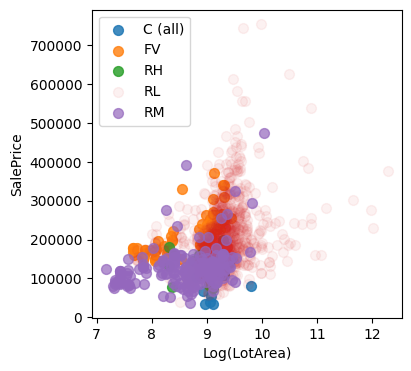

In [11]:
# Specify variables
continuous_var = 'LotArea'
categorical_var = 'MSZoning'

# Plot
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_ylabel(target_name)
ax.set_xlabel(f'Log({continuous_var})')

for zone, hunch_data in full_training.groupby(categorical_var):
    sc = ax.scatter(np.log(hunch_data[continuous_var]), hunch_data[target_name],
                    # color=colors[zone],
                    marker='o',
                    alpha=(0.85 - len(hunch_data)/num_entries),  # The more entries the lighter for visualization purposes
                    s=50,
                    label=zone)
    # sc.set_facecolor("none")

_ = ax.legend()

The distribution of the target price appears to be not normal. Let's take a quick look.

### Target variable

Start by defining a helpful function to do this for us.

In [12]:
from typing import Dict

from matplotlib.figure import Figure
from matplotlib.axes import Axes

def view_stats(data: pd.Series,
               axes: Axes, 
               scale: float = 1.0,
               bins: int = 30,
               color: str = 'blue',
               alpha: float = 1.0,
               verbose: bool = True) -> Dict:
    """
    Auxiliary function to plot and compute helpful statistics of a certain column in the dataframe

    Args:
        data: Series of data to be used
        axes: axes to be used when plotting the histogram
        scale: scale value to apply before computing statistics; defaults to 1.
        bins: number of bins to be used in histogram plot; defaults to 30
        color: color to be used; defaults to blue
        alpha: opacity to be used; defaults to 1.0 (fully opaque)
        verbose: flag to indicate whether to print statistics or not; defaults to True

    Returns:
        a dictionary containining statistics
    """
    # Compute stats
    median = (scale * data).median()
    mean = (scale * data).mean()
    std = (scale * data).std()
    skew = (scale * data).skew()
    kurtosis = (scale * data).kurtosis()

    # Store in dict
    stats = {'median': median,
             'mean': mean,
             'std': std,
             'skew': skew,
             'kurtosis': kurtosis,
             'pre_scale': scale}

    # Plot
    (data * scale).hist(bins=bins, ax=axes, color=color, alpha=alpha)

    # Print info
    if verbose:
        for key, val in stats.items():
            print(f'{key.upper()}: {val}')

    return stats

Now, let's plot the values, but scale them down so we are dealing with "units" of a thousand dollars.

MEDIAN: 163.0
MEAN: 180.92119589041096
STD: 79.4425028828866
SKEW: 1.8828757597682129
KURTOSIS: 6.5362818600645305
PRE_SCALE: 0.001


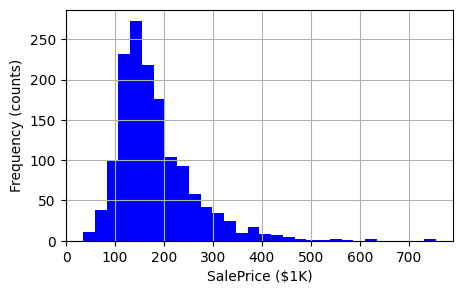

In [13]:
# Define the scaling parameter
scale=1.0e-03

# Create figure
fig, axes = plt.subplots(figsize=(5, 3))

target_stats = view_stats(data=full_training[target_name], axes=axes, scale=scale)
axes.set_xlabel(f'{target_name} ($1K)')
_ = axes.set_ylabel('Frequency (counts)')

This seems to be somewhat skewed data. This is likely due to the long right tail. Let's see if a log transformation of the data makes it a bit more Gaussian.

In [14]:
log_target_name = f"log_{target_name}"

# Let's also apply the 1K scale here for simplicity
full_training.loc[:, log_target_name] = np.log(full_training[target_name] * scale)

MEDIAN: 5.093750200806762
MEAN: 5.116295622127246
STD: 0.3994518682611643
SKEW: 0.12133506220520941
KURTOSIS: 0.8095319958036296
PRE_SCALE: 1.0


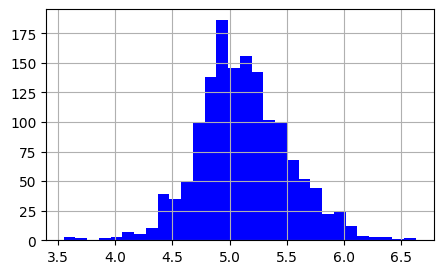

In [15]:
# Create figure
fig, axes = plt.subplots(figsize=(5, 3))

log_target_stats = view_stats(data=full_training[log_target_name], axes=axes)

This is good: it seems the log-transformed price is somewhat normally distributed, meaning it follows nice statistics for modeling.

Let's now move on to some of the other features.

### Feature analysis

We will now spend some time understanding the features of the data.

#### Missing data

We start by understanding how much data we are missing in our features.

In [16]:
feats_with_missing_data = {}

for col in full_training.columns:
    if col == target_name or col == log_target_name:
        continue
    missing_perc = 100. * full_training[col].isna().sum() / num_entries
    if missing_perc > 0:
        print(f"Feature '{col}' missing {missing_perc:.2f}% of data")
        feats_with_missing_data[col] = missing_perc

num_missing_feats = len(feats_with_missing_data)
print('=' * 120)
print(f'Total amount of features missing data = {num_missing_feats}')

Feature 'LotFrontage' missing 17.74% of data
Feature 'MasVnrArea' missing 0.55% of data
Feature 'GarageYrBlt' missing 5.55% of data
Total amount of features missing data = 3


We see there are some features that have missing entries. Let's see if the is a significant difference in the target distribution based on the fact that data is missing from these.

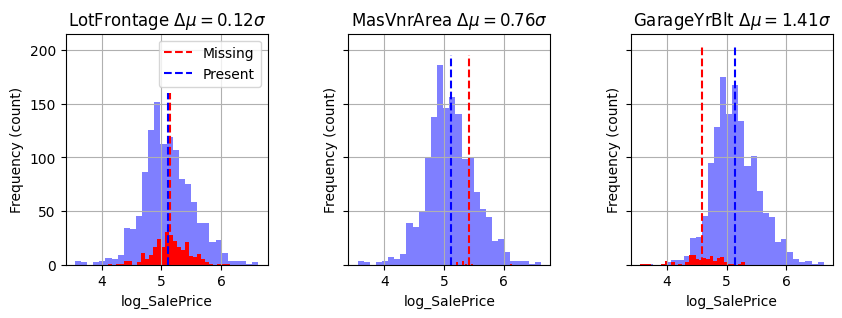

In [17]:
fig, axes = plt.subplots(1, num_missing_feats, sharey='row', figsize=(3.3 * num_missing_feats, 3))
fig.subplots_adjust(wspace=0.4)

for i, missing_feat in enumerate(list(feats_with_missing_data.keys())):
    # Set labels
    axes[i].set_ylabel('Frequency (count)')
    axes[i].set_xlabel(f'{log_target_name}')
    # Compute statistics for missing and present values
    present_stats = view_stats(data=full_training[~full_training[missing_feat].isna()][log_target_name],
                               axes=axes[i],
                               color='blue',
                               alpha=0.5,
                               verbose=False)
    missing_stats = view_stats(data=full_training[full_training[missing_feat].isna()][log_target_name],
                               axes=axes[i],
                               color='red',
                               alpha=1.,
                               verbose=False)

    # Plot the means
    ylims = axes[i].get_ylim()
    axes[i].plot([missing_stats['mean']] * 2,
                 ylims,
                 color='red',
                 linestyle='--',
                 label='Missing')
    axes[i].plot([present_stats['mean']] * 2,
                 ylims,
                 color='blue',
                 linestyle='--',
                 label='Present')

    # Set informative title
    delta_mean_rel_abs = abs(missing_stats['mean'] - present_stats['mean']) / log_target_stats['std']
    axes[i].set_title(rf'{missing_feat} $\Delta\mu=${delta_mean_rel_abs:.2f}$\sigma$')

_ = axes[0].legend()

These plots show:
1. Despite `'LotFrontage'` missing a lot of data, the missing values still somewhat follow the distribution of the general population.
2. While there are large changes in the target distribution based on the presence or absence of a `'MasVnrArea'` feature, since there are less than 10 entries missing values, it is hard to conclude any absence to be informative
3. The entries missing `'GarageYrBlt'` clearly have an impact in the target distribution, and happen often enough for that to be important. Therefore, it is likely worthwhile to add an indicator variable to help catch this.

For all three features, when training (and predicting), we will impute the median value to missing entries, but, for the specific case of `'GarageYrBlt'`, we should also add simple flag to specify whether that feature was missing or not. 

<mark>NOTE:</mark> the imputation needs to be done later, since I believe a cross-validation approach will be important, we need to make sure to use the median from the training set, not the full dataset!

#### Continuous features

Let's start our analysis with the continuous features first.

First, consider the features with highest degree of correlation with our target.

In [18]:
correlations = np.corrcoef(
    full_training[features_info['continuous']].fillna(full_training[features_info['continuous']].median()),
    full_training[log_target_name].to_numpy(),
    rowvar=False)

Now, let's order these features based on how strongly they correlate with the target variable.

In [19]:
continuous_feature_names = np.array(features_info['continuous'])

# See how to sort the correlations
corr_sort_idx = np.argsort(abs(correlations[:-1, -1]))[::-1]

continuous_feature_names = continuous_feature_names[corr_sort_idx]

Let's now plot the relationship between the top correlated features and the target. 

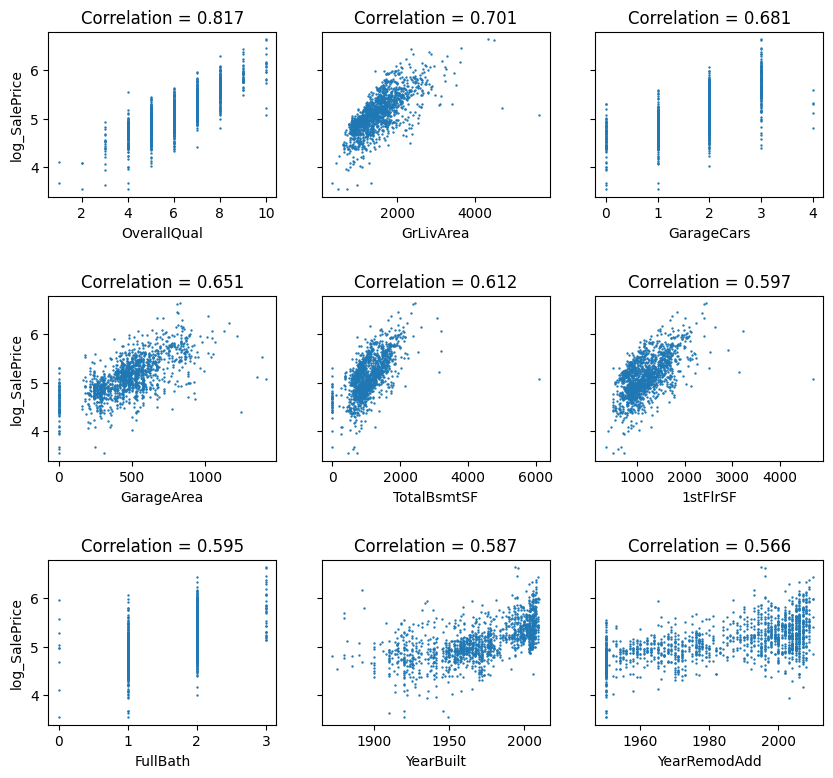

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(10, 9), sharey='all')
fig.subplots_adjust(hspace=0.6)

for i, (ind, feat_name) in enumerate(zip(corr_sort_idx[:9], continuous_feature_names[:9])):
    # Get correlation value
    correlation = correlations[ind, -1]

    # Plot
    row = i // 3
    col = i % 3
    axes[row, col].scatter(full_training[feat_name], full_training[log_target_name],
                           marker='.', s=2)

    # Set labels and title
    axes[row, col].set_xlabel(feat_name)
    if col == 0:
        axes[row, col].set_ylabel(log_target_name)
    axes[row, col].set_title(f'Correlation = {correlation:.3f}')


Let's also take a look at how these features are correlated with one another.

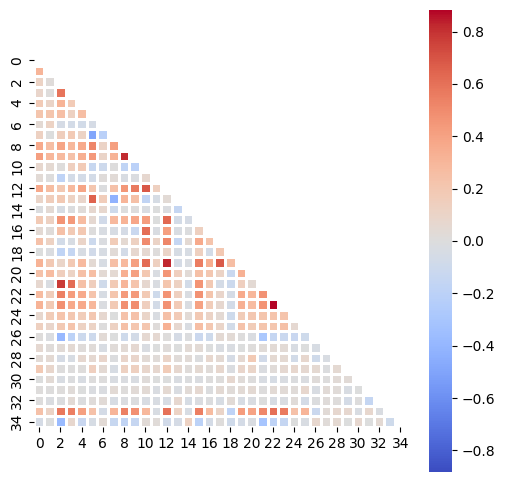

In [21]:
import seaborn

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(correlations[:-1, :-1], dtype=bool))

# Compute max absolute correlation
max_abs_cross_corr = abs(correlations[:-1, :-1][~mask]).max()

fig, axes = plt.subplots(figsize=(6, 6))

_ = seaborn.heatmap(
    correlations[:-1, :-1],  # The correlation matrix data
    mask=mask,  # Plot only the bottom
    annot=False,  # Add correlation values to the cells
    cmap="coolwarm",  # Choose a color map (e.g., "coolwarm", "viridis", "rocket")
    fmt=".2f",  # Format the annotations to 2 decimal places
    linewidths=1., # Add small gaps between cells
    square=True,  # Ensure the cells are square
    center=0,
    vmax=max_abs_cross_corr,
    vmin=-max_abs_cross_corr,
    ax=axes
)

We can see here that there are some features with high degree of correlation. This will be important when modeling. For now, let's just see some of them.

In [22]:
for i in range(len(continuous_feature_names)):
    for j in range(i+1, len(continuous_feature_names)):
        corr = correlations[i, j]
        if abs(corr) > 0.6:
            print(f'Correlation {continuous_feature_names[i]} -- {continuous_feature_names[j]}: {corr:.2f}')

Correlation GarageCars -- BsmtUnfSF: 0.78
Correlation GarageArea -- BsmtUnfSF: 0.62
Correlation 1stFlrSF -- BsmtFinSF1: 0.65
Correlation YearRemodAdd -- TotRmsAbvGrd: 0.82
Correlation GarageYrBlt -- MasVnrArea: 0.69
Correlation GarageYrBlt -- OpenPorchSF: 0.61
Correlation GarageYrBlt -- LotArea: 0.62
Correlation MasVnrArea -- WoodDeckSF: 0.63
Correlation MasVnrArea -- LotArea: 0.83
Correlation 2ndFlrSF -- LotArea: 0.68
Correlation BedroomAbvGr -- EnclosedPorch: 0.88
Correlation BedroomAbvGr -- BsmtHalfBath: 0.60


Another good check to do here is to see if the variance of our target changes too much based on the feature value (basically, we are checking for homoskedasticity). We could do so by fitting a LOWESS curve (Locally Weighted Scatterplot Smoothing) curve and seeing if the residuals are change considerably as the value of the feature changes. However, for simplicity, what I will do here is just separate the data in quantiles and make a bar-plot of the target values.

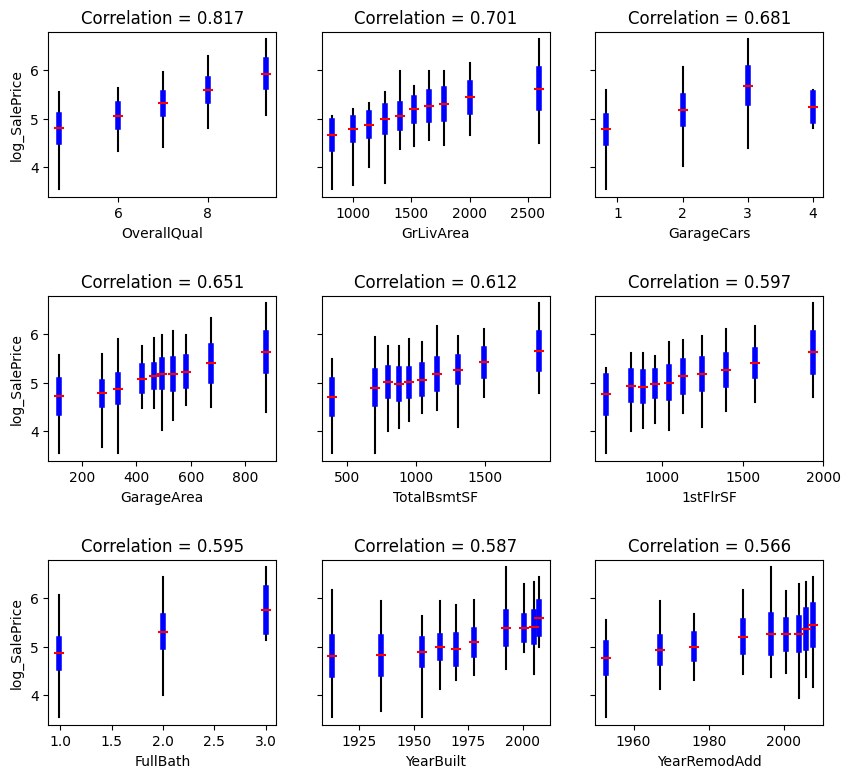

In [23]:
# Specify the quantiles to be used
quantiles = 10

fig, axes = plt.subplots(3, 3, figsize=(10, 9), sharey='all')
fig.subplots_adjust(hspace=0.6)

for i, (ind, feat_name) in enumerate(zip(corr_sort_idx[:9], continuous_feature_names[:9])):
    # Get correlation value
    correlation = correlations[ind, -1]

    # Get relevant data
    data_subset = full_training[[feat_name, log_target_name]].copy()
    data_subset['quantile_bins'] = pd.qcut(data_subset[feat_name], q=quantiles, duplicates='drop')
    # Aggregate info
    grouped = data_subset.groupby('quantile_bins', observed=False)[log_target_name].agg(['mean', 'std', 'max', 'min'])
    centers = data_subset.groupby('quantile_bins', observed=False)[feat_name].mean()

    # Plot
    row = i // 3
    col = i % 3
    for center, quantile_info in zip(centers, grouped.itertuples()):
        # Min-max (omitting for better visualization)
        axes[row, col].plot([center] * 2,
                            [quantile_info.max, quantile_info.min],
                            color='k',
                            zorder=0)

        # Mean +/- Std
        axes[row, col].plot([center] * 2,
                            [quantile_info.mean - quantile_info.std, quantile_info.mean + quantile_info.std],
                            color='blue',
                            linewidth=4,
                            zorder=1)

        # Just the mean
        axes[row, col].scatter([center], [quantile_info.mean],
                               color='red',
                               marker='_',
                               s=50,
                               zorder=2)

    # Set labels and title
    axes[row, col].set_xlabel(feat_name)
    if col == 0:
        axes[row, col].set_ylabel(log_target_name)
    axes[row, col].set_title(f'Correlation = {correlation:.3f}')

Overall, we see that
1. There are some strong relationships between our taget variable and some of the continuous features we have.
2. The target value appears relatively well behaved (homoskedastic) when investigated under the 9 top correlated features
3. However, we also saw strong degrees of cross-correlation between features, so we need to keep that in mind for later steps!

#### Categorical features

Let's now do some exploration over the categorical features

Similarly to what we have done with continuous features, we will focus here on the features with most predictive power over our target variable. In order to do so, we will use an analysis-of-variance (ANOVA) procedure, where we will investigate how much of the variance in the target can be explained by changing the category in the feature.

In [24]:
from scipy.stats import f_oneway

# Get the names of the categorical features
categorical_feature_names = np.array(list(features_info['categorical'].keys()))

# Iterate through them to compute the F-score
f_scores = []

for feat_name in categorical_feature_names:
    # Get the data for each category
    data_by_cat = [data[log_target_name] for _, data in full_training.groupby(feat_name)]

    # Compute score
    score = f_oneway(*data_by_cat)
    
    # Append to scores
    f_scores.append(score.statistic)

# Sort them
f_scores = np.array(f_scores)
f_sort_idx = np.argsort(f_scores)[::-1]
f_scores = f_scores[f_sort_idx]
categorical_feature_names = categorical_feature_names[f_sort_idx]

Now, let's plot this for the top categorical features!

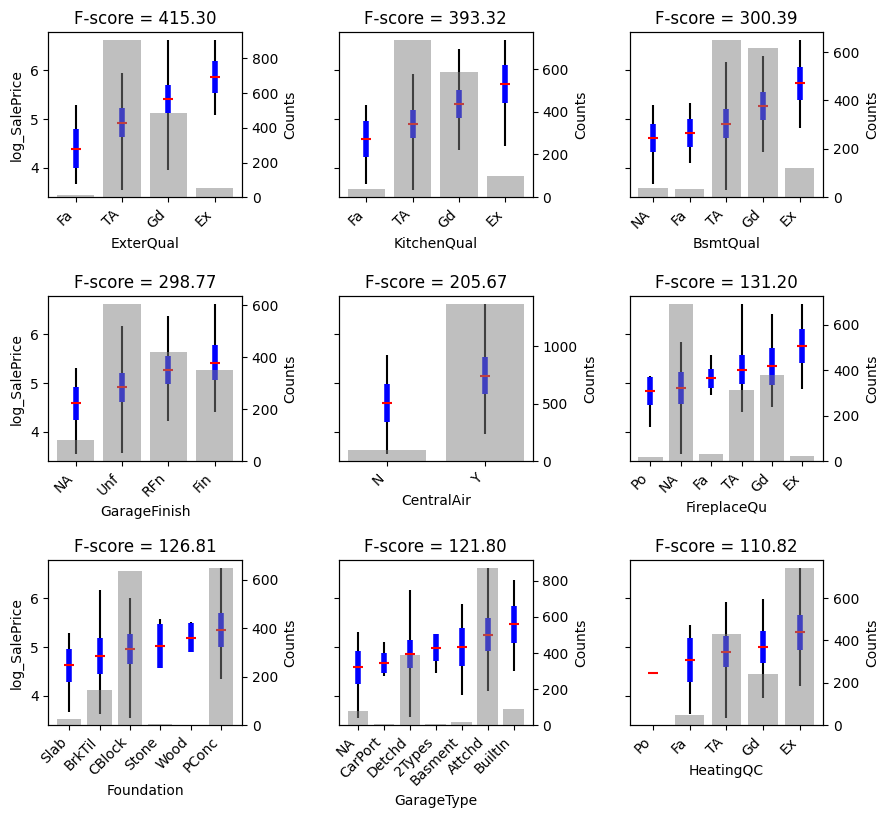

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(10, 9), sharey='all')
fig.subplots_adjust(hspace=0.6, wspace=0.5)

for i, (f_score, feat_name) in enumerate(zip(f_scores[:9], categorical_feature_names[:9])):
    # Figure out where to plot
    row = i // 3
    col = i % 3

    # Get the relevant info
    grouped = full_training.groupby(feat_name)[log_target_name].agg(
        ['mean', 'std', 'min', 'max', 'count']).sort_values('mean')

    # Plot these
    x = np.arange(len(grouped))

    # Min-max
    ax = axes[row, col].vlines(x, grouped['min'], grouped['max'],
                               color='k',
                               zorder=1)
    # Mean +/- Std
    axes[row, col].vlines(x, grouped['mean'] + grouped['std'], grouped['mean'] - grouped['std'],
                          linewidth=4,
                          color='blue',
                          zorder=2)

    # Mean
    axes[row, col].scatter(x, grouped['mean'],
                           color='red',
                           marker='_',
                           s=50,
                           zorder=3)

    # Label
    axes[row, col].set_xticks(x)
    axes[row, col].set_xticklabels(grouped.index, rotation=45, ha='right')
    axes[row, col].set_xlabel(feat_name)
    if col == 0:
        axes[row, col].set_ylabel(log_target_name)
    axes[row, col].set_title(f'F-score = {f_score:.2f}')

    # For the counts
    ax2 = axes[row, col].twinx()
    ax2.set_ylabel('Counts')
    ax2.bar(x, grouped['count'], color='gray', alpha=0.5, zorder=0)

We observe here that some of these F-scores are very large. However, we see a large difference in the means of the target variable, which explains this. Even though some of these come from relatively small groups (for example, entries with `ExterQual` being Excellent are fewer than 50), the variance of these smaller groups is not very large, and rather comparable to that of the other entries. This means that these categories generally maintain the homoskedasticity of the data, which is good.

### Conclusions

- The targed variable `'SalePrice'` is moderately skewed, but when transforming it with a $\log$ operation, it closely resembles a Gaussian distribution
- There are three features with varying degrees of missing data. Of all of them, only `'GarageYrBlt'` would benefit from also getting a missing value indicator flag when modeling.
- For the continuous features, we observe
    - Some features are highly correlated to the target
    - The target is homoskedastic to these top-correlated features
    - BUT there is a high degree of cross-correlation between some of the features, some stronger than with the target variable!!
- For the categorical features, we observe
    - high F-scores for some of them, indicating they play an important role in prediction
    - also relative homoskedasticity for the features with higher F-scores
    - some categories are poorly represented in the data, containing fewer than 50, or in extreme cases, 10 entries.

## Modeling

Now that we have completed a preliminary analysis of the data, let's move on to modeling, keeping in mind what we have already discovered.

### Baseline

We will start by creating a baseline model. 

The purpose of this is to have a simple model to which we can compare the performance of more sophisticated models. Therefore, we will stick with a linear class of models. In order to do that, we will standardize the continuous features and apply one-hot embeddings to the categorgical ones.

Since we already know that some features are highly correlated, we will need to apply a regularization penalty. We know that there are many features that are highly correlated to the target variable as well, and they are not particularly sparse. Therefore, we will opt for a Ridge version of linear regression (rather than a LASSO one). Note, however, that I believe there are some features which are not correlated to the target, so perhaps LASSO's "ability" to naturally do filter selection would be interesting in that context. 

#### Preprocessing

Let's start by preparing the pipeline to process the data.

##### Training-test split

First, for good measure, we will separate the data into a tranining and testing sets, just so we have a good way to properly validate it in unseen data.

In [26]:
from sklearn.model_selection import train_test_split

# Separate the features from the target
features = full_training[continuous_feature_names.tolist() + categorical_feature_names.tolist()].copy()
target = full_training[log_target_name].copy()

Let's not forget to add a missingn indicator to `'GarageYrBlt'`!

In [27]:
needs_missing_flag = ['GarageYrBlt']

for col in needs_missing_flag:
    features.loc[:, f'missing_{col}'] = features[col].isna().astype(int)

Now, split into training and testing. For this case, let's save 10% of the data aside for "independent" testing.

In [28]:
# Split training and test
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.1, random_state=12345)

##### Transforming features

Let's now make sure we:
1. standardize the continuous features
    - but use median imputation when values are missing (since we have a features where ~17% entries are missing values, the imputation can be very sensitive to outliers, making a median strategy safer than mean)
2. one-hot encode the categorical features
    - we will use a `drop='first'` strategy, which is unnecessary for Ridge, but can be useful for other linear models to avoid collinearity of features
    - we will also ignore unknown categories to avoid issues when the validation fold contains categories not present in the training. 
3. don't change the indicator flags.

In [29]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# For the continuous features, we will do the usual standardization.
continuous_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
    ])

# For the categorical ones, we will one-hot encode
one_hot_encoder = OneHotEncoder(
    drop='first',  # Avoiding collinear features; not a problem for Ridge, but good practice
    handle_unknown='ignore'  # If a cross-validation set has a category not in the training, it won't cause an error
    )
categorical_pipeline = Pipeline([('one_hot', one_hot_encoder)])

# For the indicator flags, we just skip them
indicator_pipeline = "passthrough"

# Prepare the full preprocessor
preprocessor = ColumnTransformer([
    ("continuous", continuous_pipeline, continuous_feature_names.tolist()),
    ("indicator", indicator_pipeline, [f'missing_{feat}' for feat in needs_missing_flag]),
    ("categorical", categorical_pipeline, categorical_feature_names.tolist())
])

#### Fitting

Now, let's fit the data. We will employ a nested cross-validation strategy: we will use 10 folds to split into different training and testing, and, in each case, use 5 folds to optimize the regularization penalty parameter.

Start by the main pipeline.

In [30]:
from sklearn.linear_model import RidgeCV

# Prepare the different alphas (regularization parameters) to try out
alphas = np.logspace(-3, 3, 50)  # Log-space ensures we sample from several orders of magnitude of penalties

# Prepare the model pipeline
inner_folds = 5
ridge_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RidgeCV(alphas=alphas, cv=inner_folds))
])

Now, let's do the external cross-validation to make sure we understand our generalization error.

In [31]:
from sklearn.model_selection import cross_val_score

# Prepare the outer CV
outer_folds = 10
ridge_scores = cross_val_score(
    ridge_pipeline,
    X_train,
    y_train,
    cv=outer_folds,
    scoring="neg_root_mean_squared_error"
)

/Users/vventuri/python_venvs/kaggle_env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [24, 26] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/vventuri/python_venvs/kaggle_env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [33, 40] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/vventuri/python_venvs/kaggle_env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [41] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/vventuri/python_venvs/kaggle_env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [30, 41] during transform. These unknown categories will be encoded as all zer

In [32]:
print(f'Expected RMSE: {-ridge_scores.mean():.3f}')
print(f'Variation in RMSE: {ridge_scores.std():.3f}')

Expected RMSE: 0.141
Variation in RMSE: 0.044


Finally, let's fit the model!

In [33]:
ridge_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['OverallQual', 'GrLivArea',
                                                   'GarageCars', 'GarageArea',
                                                   'TotalBsmtSF', '1stFlrSF',
                                                   'FullBath', 'YearBuilt',
                                                   'YearRemodAdd',
                                                   'TotRmsAbvGrd',
                                                   'GarageYrBlt', 'Fireplaces',
                                                   'MasVnrArea', 'BsmtFinSF1'...
       8.68511374e-01, 1.15139540e+00, 1.52641797e+00, 2.02358965e+00,
       2.68269580e+00, 3.55648031e+00, 4.71486636e+00, 6.25055193e+00,
       8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
       2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
       7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
       2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
       7.54312006e+02, 1.00000000e+03]),
                         cv=5))])

#### Evaluation

Finally, let's see how this baseline Ridge Linear Regression model performs on both the traning and the pseudo-test data.

In [34]:
# Predict values
y_train_ridge_pred = ridge_pipeline.predict(X_train)
y_test_ridge_pred = ridge_pipeline.predict(X_test)

/Users/vventuri/python_venvs/kaggle_env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [35]:
# Compute errors
y_train_ridge_err = y_train - y_train_ridge_pred
y_test_ridge_err = y_test - y_test_ridge_pred

In [36]:
print('Target standard deviation')
print(f'sigma = {full_training[log_target_name].std():.3f}')
print('=' * 30)
print('From Generalization CV')
print(f'RMSE = {-ridge_scores.mean():.3f}')
print('=' * 30)
print('Training')
print(f'RMSE = {np.sqrt(np.pow(y_train_ridge_err, 2).mean()):.3f}')
print('=' * 30)
print('Test')
print(f'RMSE = {np.sqrt(np.pow(y_test_ridge_err, 2).mean()):.3f}')

Target standard deviation
sigma = 0.399
From Generalization CV
RMSE = 0.141
Training
RMSE = 0.118
Test
RMSE = 0.110


Now that we have an understanding of the baseline model, let's try other models.

### Random Forest

Another approach we can try is the use of Random Forests. They can deal with collinearity natively, are not too problematic with categories with low representation, and are generally robust agains overfitting. 

#### Preprocessing

Similarly to before, we need to preprocess the data. This case, however, is a bit simpler, as the continuous features do not need to be scaled, and categories should not be dropped, as collinearity is not an issue. 

In [37]:
# For the continuous features, we will do the usual standardization.
continuous_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median"))
    ])

# For the categorical ones, we will one-hot encode
one_hot_encoder = OneHotEncoder(
    handle_unknown='ignore'  # If a cross-validation set has a category not in the training, it won't cause an error
    )
categorical_pipeline = Pipeline([('one_hot', one_hot_encoder)])

# For the indicator flags, we just skip them
indicator_pipeline = "passthrough"

# Prepare the full preprocessor
preprocessor = ColumnTransformer([
    ("continuous", continuous_pipeline, continuous_feature_names.tolist()),
    ("indicator", indicator_pipeline, [f'missing_{feat}' for feat in needs_missing_flag]),
    ("categorical", categorical_pipeline, categorical_feature_names.tolist())
])

#### Model definition

We can now define the model.

We will (at least start with) a forest made up of 500 trees, allowed to grow as deep as they need, but making sure every leaf has at least 10 samples. We will also only allow each tree to see $\sqrt{p}$ number of features, where $p$ is the total number of features after one-hot encodding. This will help with regularization and keeping the trees uncorrelated (thereby reducing the variance of the estimates, but increading the bias). For now, we will allow each tree the see every entry in the dataset, but we can tune that down later if needed.

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=500,  # Use a large number of trees
    bootstrap=True,  # This will ensure proper sampling of the distribution if we reduce max_samples
    max_samples=1.0,  # Each tree only sees about 80% of the data
    max_depth=None,  # For now, let the trees grow as much as they need
    min_samples_leaf=10,  # All leaf nodes must have at least 10 samples
    max_features="sqrt",  # Make sure each tree only sees a fraction of the features to reduce variance in prediction
    random_state=42,
    n_jobs=-1  # parallelize
)

In [39]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

In [40]:
scoring = "neg_root_mean_squared_error"

rf_scores = cross_val_score(
    rf_pipeline,
    X_train,  # training features
    y_train,  # log-transformed target
    cv=outer_folds,
    scoring=scoring,
    n_jobs=-1  # parallelize
)

In [41]:
print(f'Expected RMSE: {-rf_scores.mean():.3f}')
print(f'Variation in RMSE: {rf_scores.std():.3f}')

Expected RMSE: 0.170
Variation in RMSE: 0.014


What we can conclude from this is that the random forests have a larger RMSE than the baseline Ridge regression, indicating that linearity probably dominates the signal we are trying to capture. However, it is interesting to see the trees being much more robust against variations in the data. 

Let's still fit the model with the whole dataset for completeness.

In [42]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['OverallQual', 'GrLivArea',
                                                   'GarageCars', 'GarageArea',
                                                   'TotalBsmtSF', '1stFlrSF',
                                                   'FullBath', 'YearBuilt',
                                                   'YearRemodAdd',
                                                   'TotRmsAbvGrd',
                                                   'GarageYrBlt', 'Fireplaces',
                                                   'MasVnrArea', 'BsmtFinSF1',
                                                   'LotFrontage', 'WoodDeckSF...
                                                   'PavedDrive', 'BsmtFinType1',
                                                   'BsmtExposure', 'MSSubClass',
                                                   'GarageCond', 'GarageQual',
                                                   'LotShape', 'SaleCondition',
                                                   'BsmtCond', 'Electrical',
                                                   'SaleType', 'HouseStyle',
                                                   'Exterior1st', 'Alley',
                                                   'Exterior2nd', 'ExterCond',
                                                   'Fence', 'BldgType', ...])])),
                ('model',
                 RandomForestRegressor(max_features='sqrt', max_samples=1.0,
                                       min_samples_leaf=10, n_estimators=500,
                                       n_jobs=-1, random_state=42))])

##### Feature importance

It is interesting to see the how the trees assign importance to the features.

In [43]:
# For indicator features
ind_features = [f'missing_{col}' for col in needs_missing_flag]
# For categorical features (after OHE)
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['categorical'].named_steps['one_hot']
cat_features = ohe.get_feature_names_out(categorical_feature_names)

# Combine all
all_features = np.concatenate([continuous_feature_names, ind_features, cat_features])

In [44]:
# Get importances
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create DataFrame for convenience
feat_imp_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
})

# Sort descending
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

Recall that this attributes separate importances to each of the one-hot encoded columns, so we need to make sure to aggregate them together. 

In [45]:
agg_list = []

for feat in continuous_feature_names.tolist() + ind_features:
    imp = feat_imp_df.loc[feat_imp_df['feature'] == str(feat), 'importance'].values[0]
    agg_list.append({'feature': feat, 'importance': imp})

# Now do categorical variables
for cat_feat in categorical_feature_names:
    mask = feat_imp_df['feature'].str.startswith(cat_feat + "_")
    total_imp = feat_imp_df.loc[mask, 'importance'].sum()
    agg_list.append({'feature': cat_feat, 'importance': total_imp})

# Build final aggregated DataFrame
agg_feat_imp_df = pd.DataFrame(agg_list)

# Sort descending
agg_feat_imp_df = agg_feat_imp_df.sort_values(by='importance', ascending=False)

Plot them!

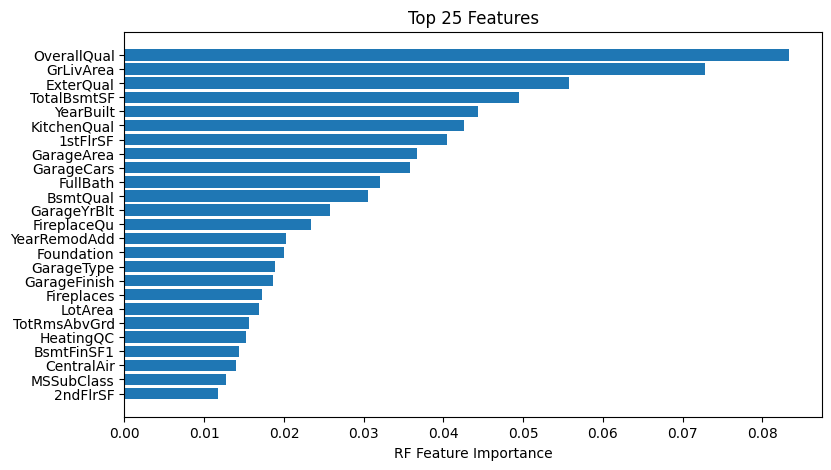

In [46]:
# Number features to plot
num_total_feat_import_plot = 25

fig, axes = plt.subplots(figsize=(9, 5))

axes.barh(agg_feat_imp_df['feature'].iloc[:num_total_feat_import_plot][::-1],
          feat_imp_df['importance'].iloc[:num_total_feat_import_plot][::-1])
axes.set_xlabel('RF Feature Importance')
_ = axes.set_title(f'Top {num_total_feat_import_plot} Features')

As expetected, the `'OverallQual'` and `'GrLivArea'` are the top feature, which we sort of already knew from our EDA steps. This is nice to see!

#### Evaluation

Check how well it performs on new data.

In [47]:
# Predict values
y_train_RF_pred = rf_pipeline.predict(X_train)
y_test_RF_pred = rf_pipeline.predict(X_test)

In [48]:
# Compute errors
y_train_RF_err = y_train - y_train_RF_pred
y_test_RF_err = y_test - y_test_RF_pred

In [49]:
print('Target standard deviation')
print(f'sigma = {full_training[log_target_name].std():.3f}')
print('=' * 30)
print('From Generalization CV')
print(f'RMSE = {-rf_scores.mean():.3f}')
print('=' * 30)
print('Training')
print(f'RMSE = {np.sqrt(np.pow(y_train_RF_err, 2).mean()):.3f}')
print('=' * 30)
print('Test')
print(f'RMSE = {np.sqrt(np.pow(y_test_RF_err, 2).mean()):.3f}')

Target standard deviation
sigma = 0.399
From Generalization CV
RMSE = 0.170
Training
RMSE = 0.151
Test
RMSE = 0.146


We can see that this model does not perform as well as our baseline ridge regression, so let's move on to another one.

### Boosting

Now, it's time we try a boosting appproach instead, in which each new tree is going to try to learn to fix the errors from the previous trees. 

#### Preprocessing

Similar to before, let's preprocess the data. Here, we intend to use an approach that can handle categorical features natively, so we will not one-hot encode them.

In [50]:
# Continuous pipeline (scaling optional)
continuous_pipeline = Pipeline([
    ('scaler', StandardScaler())  # optional
])

# For categorical + missing indicators, just passthrough
categorical_pipeline = "passthrough"
indicator_pipeline = "passthrough"

# Full preprocessor
preprocessor = ColumnTransformer([
    ("continuous", continuous_pipeline, continuous_feature_names.tolist()),
    ("indicator", indicator_pipeline, needs_missing_flag),
    ("categorical", categorical_pipeline, categorical_feature_names.tolist())
])

#### Model definition

We can now define our model using the `HistGradientBoostingRegressor` method.

In [51]:
from sklearn.ensemble import HistGradientBoostingRegressor

# We need to prepare a mask to specify which features are categorical
cat_mask = np.zeros_like(continuous_feature_names.tolist() + needs_missing_flag + categorical_feature_names.tolist(),
                         dtype=bool)
cat_mask[-len(categorical_feature_names):] = True

boost_model = HistGradientBoostingRegressor(
    max_iter=1000,  # number of boosting iterations
    learning_rate=0.01,  # smaller LR usually works better
    max_depth=4,  # keep them shallow
    min_samples_leaf=20,  # make sure leaves have some good amount of data
    categorical_features=cat_mask,  # specify categorical features
    max_features=0.8,  # regularization, ensure each tree only sees a fraction of the total features
    random_state=98765
)

In [52]:
boost_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", boost_model)
])

Compute CV scores.

In [53]:
boost_scores = cross_val_score(
    boost_pipeline,
    X_train,
    y_train,  # log-transformed target
    cv=outer_folds,
    scoring="neg_root_mean_squared_error"
)

In [54]:
print(f'Expected RMSE: {-boost_scores.mean():.3f}')
print(f'Variation in RMSE: {boost_scores.std():.3f}')

Expected RMSE: 0.130
Variation in RMSE: 0.014


This looks very promising! It has an RMSE comparable to ridge regression, but with a standard deviation that is even better than from the random forest! Let's fit it.

In [55]:
boost_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('continuous',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['OverallQual', 'GrLivArea',
                                                   'GarageCars', 'GarageArea',
                                                   'TotalBsmtSF', '1stFlrSF',
                                                   'FullBath', 'YearBuilt',
                                                   'YearRemodAdd',
                                                   'TotRmsAbvGrd',
                                                   'GarageYrBlt', 'Fireplaces',
                                                   'MasVnrArea', 'BsmtFinSF1',
                                                   'LotFrontage', 'WoodDeckSF',
                                                   'OpenPorchSF', '2n...
       False, False, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True]),
                                               learning_rate=0.01, max_depth=4,
                                               max_features=0.8, max_iter=1000,
                                               random_state=98765))])

#### Evaluation

In [56]:
# Predict values
y_train_boost_pred = boost_pipeline.predict(X_train)
y_test_boost_pred = boost_pipeline.predict(X_test)

In [57]:
# Compute errors
y_train_boost_err = y_train - y_train_boost_pred
y_test_boost_err = y_test - y_test_boost_pred

In [58]:
print('Target standard deviation')
print(f'sigma = {full_training[log_target_name].std():.3f}')
print('=' * 30)
print('From Generalization CV')
print(f'RMSE = {-boost_scores.mean():.3f}')
print('=' * 30)
print('Training')
print(f'RMSE = {np.sqrt(np.pow(y_train_boost_err, 2).mean()):.3f}')
print('=' * 30)
print('Test')
print(f'RMSE = {np.sqrt(np.pow(y_test_boost_err, 2).mean()):.3f}')

Target standard deviation
sigma = 0.399
From Generalization CV
RMSE = 0.130
Training
RMSE = 0.074
Test
RMSE = 0.113


These results are not as promising. While the model is evidently very capable in the training data, it appears to struggle to generalize, given the large discrepancy in RMSE between training and testing. While we only perfomed a hyper-parameter optimization for Ridge Regression, it seems like that is indeed the best model to use for this problem, given how the test RMSE for both random forest and boosting methods are higher. 

## Prediction

Now that we have investigated a number of models, it is time to use them to predict unseen data.

### Reading in data

In [59]:
new_data = pd.read_csv(input_dir + 'house-prices-advanced-regression-techniques/test.csv',
                            keep_default_na=False,  # Recall some of the categories are 'NA'
                            na_values=na_values,
                            )

### Preparing for prediction

Remember we have to add a missing indicator flag.

In [60]:
for col in needs_missing_flag:
    new_data.loc[:, f'missing_{col}'] = new_data[col].isna().astype(int)

Check if anything else has missing data!

In [61]:
for col in new_data.columns:
    isna = new_data[col].isna()
    if isna.sum() > 0:
        print(f"Feature '{col}' has {isna.sum()} NaN!")

Feature 'LotFrontage' has 227 NaN!
Feature 'MasVnrArea' has 15 NaN!
Feature 'BsmtFinSF1' has 1 NaN!
Feature 'BsmtFinSF2' has 1 NaN!
Feature 'BsmtUnfSF' has 1 NaN!
Feature 'TotalBsmtSF' has 1 NaN!
Feature 'BsmtFullBath' has 2 NaN!
Feature 'BsmtHalfBath' has 2 NaN!
Feature 'GarageYrBlt' has 78 NaN!
Feature 'GarageCars' has 1 NaN!
Feature 'GarageArea' has 1 NaN!


Unfortunately, we see there are more features with missing data than in the training set. Luckily, the main ones are still the same as before: `'LotFrontage'`, `'GarageYrBlt'`, and `'MasVnrArea'`.

This shouldn't be too problematic, as our ridge regressor already has ways of dealing with these situations. For these expected missing features, it will impute the mean, and, for the missing categorical ones, it will simply assign zero to all the appropriate one-hot encodings.

#### Get the features only

In [62]:
X_new_data = new_data[continuous_feature_names.tolist() + 
                      categorical_feature_names.tolist() + 
                      [f'missing_{col}' for col in needs_missing_flag]]

## Predict

Let's start by simply predicting

In [63]:
y_new = ridge_pipeline.predict(X_new_data)

/Users/vventuri/python_venvs/kaggle_env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 11, 15, 22, 24, 26, 27, 36, 43] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Recall, however, that these are the predictions of $z=\log(y)$, but we are interested in $y=e^z$. 

Note that this is not as simple as exponentiating the prediction, seeing and $\mathbb{E}[Y] \ne \mathbb{E}[e^{\hat{z}}]$. This is because our predictor $Z$ follows a $\mathcal{N}\left(\mathbb{E}[\log(y), \sigma^2\right)$ normal distribution, where $\sigma$ is the standard error we computed before (the RMSE in the test set). Exponentiating values that are one standard deviation above or below the mean does not place them symmetrically on the target distribution! Truly, what we have is:
\begin{align*}
\mathbb{E}[Y] &= \frac{1}{\sqrt{2\pi\sigma^2}}\int\limits_{-\infty}^{\infty}e^z\cdot \exp\left[-\frac{(z-\hat{z})^2}{2\sigma^2}\right]dz \\
&= \frac{1}{\sqrt{2\pi\sigma^2}}\int\limits_{-\infty}^{\infty}\exp\left[\frac{2z\sigma^2 - z^2 + 2z\hat{z} - \hat{z}^2}{2\sigma^2}\right]dz\\
&= \frac{1}{\sqrt{2\pi\sigma^2}}\int\limits_{-\infty}^{\infty}\exp\left[\frac{-(z-(\hat{z}+\sigma^2))^2 + 2\hat{z}\sigma^2+\sigma^4}{2\sigma^2}\right]dz \\
&= \frac{1}{\sqrt{2\pi\sigma^2}}\int\limits_{-\infty}^{\infty}\exp\left(\hat{z} + \frac{\sigma^2}{2}\right)\cdot\exp\left[\frac{-(z-(\hat{z}+\sigma^2))^2}{2\sigma^2}\right]dz \Rightarrow\\
\mathbb{E}[Y] &= \exp\left(\hat{z} + \frac{\sigma^2}{2}\right)
\end{align*}

<mark>NOTE 1:</mark> Remember that we need to use the unbiased variance of the estimations, that is, the sum of squared residuals divided by $N-p-1$, where $N$ is the number of samples (the cardinality of the dataset) and $p$ is the number of model parameters. 

<mark>NOTE 2:</mark> Recall that we also applied a scale when taking the log, so we need to apply it back at the end too!!

In [64]:
# Number parameters
num_param = len(X_train.columns) + 1  # don't forget the bias/y-intercept term
sigma2 = np.sum(y_test_ridge_err ** 2) / (num_entries - num_param - 1)

y_pred = np.exp(y_new + (sigma2/2.)) / scale

Finally, let's assemble this in a dataframe.

In [65]:
submission_dataframe = new_data[['Id']].copy()

submission_dataframe.loc[:, target_name] = y_pred

submission_dataframe.head(10)

,Id,SalePrice
0,1461,112445.355493
1,1462,146433.327976
2,1463,170956.097607
3,1464,198143.812906
4,1465,194589.796473
5,1466,169799.396719
6,1467,180268.860583
7,1468,163811.162818
8,1469,188569.357515
9,1470,120669.794760


Save it to a `.csv` for submission!

In [66]:
submission_dataframe.to_csv('submission.csv', index=False)